# Note-Aligned Two-Class Model and Behavior Choices

This notebook follows [the formulation note](../Documents/generated_notes/first_two_class_simulation_note.pdf) as the source of truth.
It is the compact notebook to understand the model before running the FCFS simulation.

## Sections
- 1. Working inputs
- 2. Core objects from the note
- 3. Available options for `b_i(\tau)`, `\phi_i(\tau)`, and `\xi_i(\tau)`
- 4. The selected profile used in the simulation notebook


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from appointment_simulation import (
    BALKING_OPTIONS,
    CANCELLATION_OPTIONS,
    NO_SHOW_OPTIONS,
    behavior_option_frame,
    behavior_profile_frame,
    make_two_class_classes,
    model_setup_frame,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Working Inputs

Edit only this cell if you want to change the working mix `(\lambda, p)` or the active behavior choices.
The three behavior families are kept explicit so the notebook stays close to the note.


In [2]:
TOTAL_LAMBDA = 0.24
CLASS_1_SHARE = 7 / 12
HORIZON_DAYS = 15

SELECTED_BALKING = "step_access"
SELECTED_CANCELLATION = "moderate"
SELECTED_NO_SHOW = "source_aligned"

CLASS_CONFIGS = make_two_class_classes(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    balking_option=SELECTED_BALKING,
    cancellation_option=SELECTED_CANCELLATION,
    no_show_option=SELECTED_NO_SHOW,
)

MODEL_SETUP = model_setup_frame(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    class_configs=CLASS_CONFIGS,
    balking_option=SELECTED_BALKING,
    cancellation_option=SELECTED_CANCELLATION,
    no_show_option=SELECTED_NO_SHOW,
)

display(MODEL_SETUP)


,class_id,label,lambda_total,p,lambda_i,b_i option,phi_i option,xi_i option,bar_phi_i
0,1,MRI-like diagnostic,0.24,0.583333,0.14,step_access,moderate,source_aligned,0.08
1,2,Behavioral-health follow-up,0.24,0.583333,0.10,step_access,moderate,source_aligned,0.12


## 2. Core Objects From the Note

The note distinguishes clearly between the time index, the true calendar state, and the behavioral delay.

- `t = (D, s)` is the decision epoch: current day `D`, current slot `s`
- `Y_t(r, m)` is the rolling calendar state: day-ahead row `r`, slot-within-day column `m`
- `X_{i,r}^D` is the derived day-start count: how many class-`i` patients are scheduled for day `D+r`
- `\tau` is the booking-time delay accepted by the patient, and it is the input to `b_i(\tau)`, `\phi_i(\tau)`, and `\xi_i(\tau)`
- demand is parameterized by total `\lambda` and share `p`, with `\lambda_1 = p\lambda` and `\lambda_2 = (1-p)\lambda`


In [3]:
notation_frame = pd.DataFrame(
    [
        {"object": "t = (D, s)", "role": "Current decision epoch", "read_as": "day D, slot s"},
        {"object": "Y_t(r, m)", "role": "True calendar state", "read_as": "content of one future calendar cell"},
        {"object": "X_{i,r}^D", "role": "Derived day-start state", "read_as": "class-i patients scheduled for day D+r"},
        {"object": "tau", "role": "Behavioral delay", "read_as": "delay offered and accepted at booking time"},
        {"object": "lambda, p", "role": "Demand inputs", "read_as": "total arrival rate and class-1 share"},
    ]
)

display(notation_frame)


,object,role,read_as
0,"t = (D, s)",Current decision epoch,"day D, slot s"
1,"Y_t(r, m)",True calendar state,content of one future calendar cell
2,"X_{i,r}^D",Derived day-start state,class-i patients scheduled for day D+r
3,tau,Behavioral delay,delay offered and accepted at booking time
4,"lambda, p",Demand inputs,total arrival rate and class-1 share


## 3. Available Behavior Options

The next cells expose two realistic options for each family of functions. The classes stay different under each option, so the notebook is still clinically interpretable.


In [4]:
OPTION_TABLE = behavior_option_frame()

def profile_for_family(family: str, option_name: str) -> pd.DataFrame:
    """Build a behavior table while varying only one family of functions."""
    choices = {
        "balking_option": SELECTED_BALKING,
        "cancellation_option": SELECTED_CANCELLATION,
        "no_show_option": SELECTED_NO_SHOW,
    }
    family_to_key = {
        "balking": "balking_option",
        "cancellation": "cancellation_option",
        "no_show": "no_show_option",
    }
    choices[family_to_key[family]] = option_name
    classes = make_two_class_classes(
        total_lambda=TOTAL_LAMBDA,
        class_1_share=CLASS_1_SHARE,
        **choices,
    )
    frame = behavior_profile_frame(classes, horizon_days=HORIZON_DAYS).rename(columns={"tau_booked": "tau"})
    frame["option"] = option_name
    return frame


def plot_family_options(family: str, metric: str, title: str, ylabel: str) -> None:
    """Plot the two realistic options for one behavior family, class by class."""
    option_map = {
        "balking": BALKING_OPTIONS,
        "cancellation": CANCELLATION_OPTIONS,
        "no_show": NO_SHOW_OPTIONS,
    }[family]
    plot_df = pd.concat(
        [profile_for_family(family, option_name) for option_name in option_map],
        ignore_index=True,
    )
    labels = plot_df[["class_id", "label"]].drop_duplicates().sort_values("class_id")

    fig, axes = plt.subplots(1, len(labels), figsize=(13, 4), sharex=True, sharey=True)
    if len(labels) == 1:
        axes = [axes]

    for ax, (_, class_row) in zip(axes, labels.iterrows()):
        class_df = plot_df[plot_df["class_id"] == class_row["class_id"]]
        sns.lineplot(data=class_df, x="tau", y=metric, hue="option", marker="o", ax=ax)
        ax.set_title(class_row["label"])
        ax.set_xlabel(r"Accepted delay $\tau$ (days)")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1)
        ax.legend(title="option")

    fig.suptitle(title, y=1.05)
    plt.tight_layout()


In [5]:
display(
    OPTION_TABLE.pivot_table(
        index=["family", "option", "description"],
        columns="label",
        values="details",
        aggfunc="first",
    )
)


label                                                                                                       Behavioral-health follow-up  \
family       option               description                                                                                             
balking      smooth_access        Smoother logistic balking when patients gradual...  logistic midpoint=12, slope=0.40, floor=0.04, ...   
             step_access          Step balking around a practical access threshol...             step threshold=14, low=0.04, high=0.72   
cancellation moderate             Moderate eventual cancellation before the visit.                                 eventual cancel=0.12   
             reschedule_heavy     Higher eventual cancellation, consistent with m...                               eventual cancel=0.20   
no_show      more_delay_sensitive A stronger delay effect to stress-test the feed...        gamma_0=0.18, gamma_max=0.62, sensitivity=6   
             source_aligned       Green-Savin style curves close to the literatur...        gamma_0=0.15, gamma_max=0.51, sensitivity=9   

label                                                                                                               MRI-like diagnostic  
family       option               description                                                                                            
balking      smooth_access        Smoother logistic balking when patients gradual...  logistic midpoint=18, slope=0.30, floor=0.02, ...  
             step_access          Step balking around a practical access threshol...             step threshold=21, low=0.02, high=0.55  
cancellation moderate             Moderate eventual cancellation before the visit.                                 eventual cancel=0.08  
             reschedule_heavy     Higher eventual cancellation, consistent with m...                               eventual cancel=0.14  
no_show      more_delay_sensitive A stronger delay effect to stress-test the feed...       gamma_0=0.02, gamma_max=0.38, sensitivity=28  
             source_aligned       Green-Savin style curves close to the literatur...       gamma_0=0.01, gamma_max=0.31, sensitivity=50

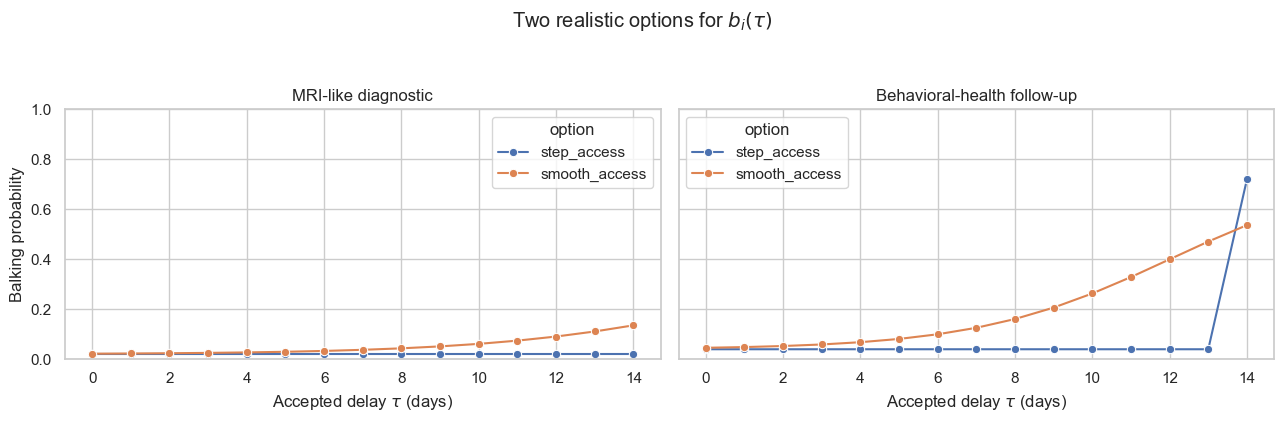

In [6]:
plot_family_options(
    family="balking",
    metric="balk_probability",
    title=r"Two realistic options for $b_i(\tau)$",
    ylabel="Balking probability",
)


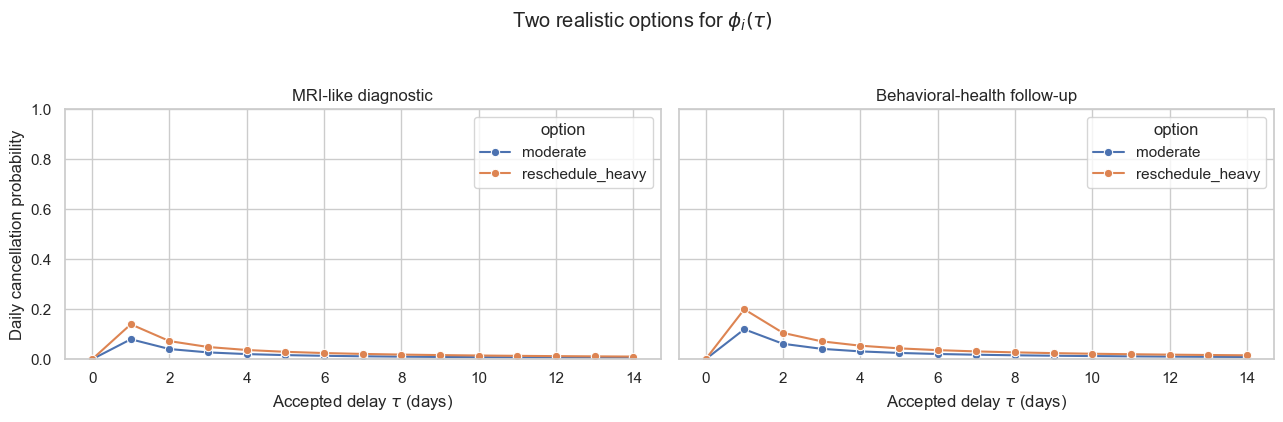

In [7]:
plot_family_options(
    family="cancellation",
    metric="daily_cancel_probability",
    title=r"Two realistic options for $\phi_i(\tau)$",
    ylabel="Daily cancellation probability",
)


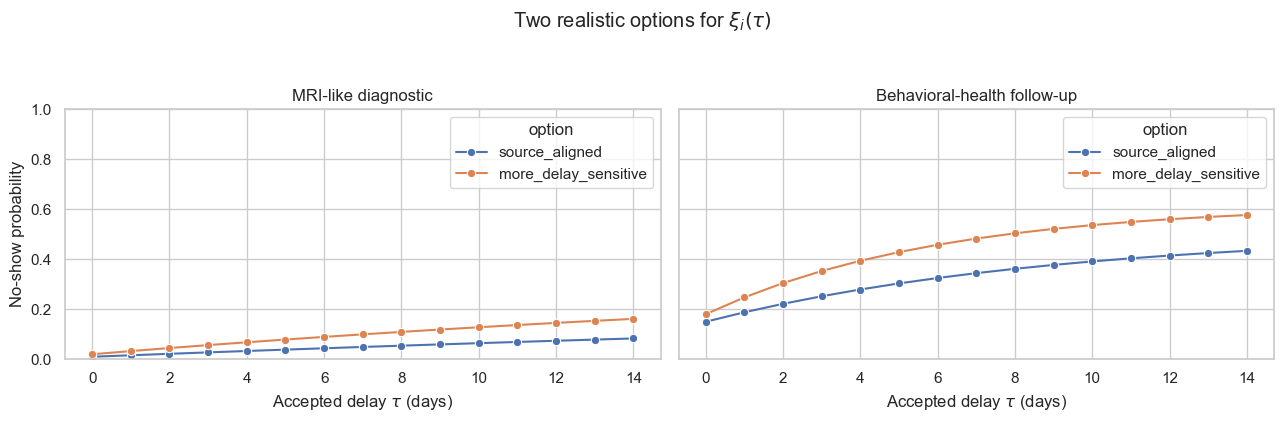

In [8]:
plot_family_options(
    family="no_show",
    metric="no_show_probability",
    title=r"Two realistic options for $\xi_i(\tau)$",
    ylabel="No-show probability",
)


## 4. The Selected Profile Used in the FCFS Simulation Notebook

This is the one active profile used in the baseline FCFS simulation notebook. Change the three option names at the top if you want to study another combination.


In [9]:
SELECTED_PROFILE = behavior_profile_frame(CLASS_CONFIGS, horizon_days=HORIZON_DAYS).rename(
    columns={
        "tau_booked": "tau",
        "eventual_cancel_probability": "bar_phi_i",
        "daily_cancel_probability": "phi_i(tau)",
    }
)

display(SELECTED_PROFILE.head(10))


,class_id,label,tau,balk_probability,no_show_probability,bar_phi_i,phi_i(tau)
0,1,MRI-like diagnostic,0,0.02,0.010000,0.00,0.000000
1,1,MRI-like diagnostic,1,0.02,0.015940,0.08,0.080000
2,1,MRI-like diagnostic,2,0.02,0.021763,0.08,0.040834
3,1,MRI-like diagnostic,3,0.02,0.027471,0.08,0.027411
4,1,MRI-like diagnostic,4,0.02,0.033065,0.08,0.020630
5,1,MRI-like diagnostic,5,0.02,0.038549,0.08,0.016538
6,1,MRI-like diagnostic,6,0.02,0.043924,0.08,0.013801
7,1,MRI-like diagnostic,7,0.02,0.049193,0.08,0.011841
8,1,MRI-like diagnostic,8,0.02,0.054357,0.08,0.010369
9,1,MRI-like diagnostic,9,0.02,0.059419,0.08,0.009222


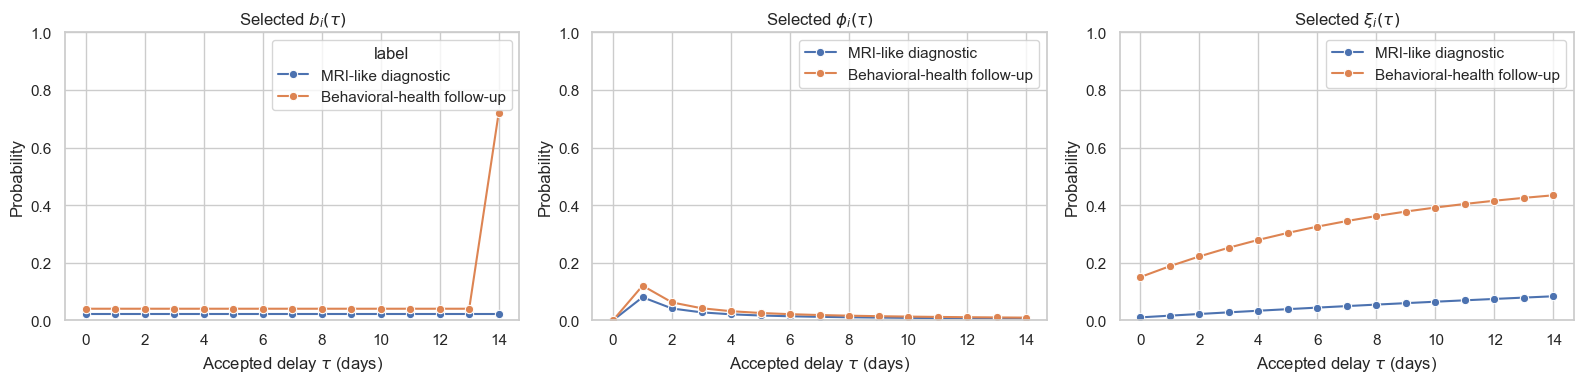

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

sns.lineplot(data=SELECTED_PROFILE, x="tau", y="balk_probability", hue="label", marker="o", ax=axes[0])
axes[0].set_title(r"Selected $b_i(\tau)$")
axes[0].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)

sns.lineplot(data=SELECTED_PROFILE, x="tau", y="phi_i(tau)", hue="label", marker="o", ax=axes[1])
axes[1].set_title(r"Selected $\phi_i(\tau)$")
axes[1].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1)
axes[1].legend(title="")

sns.lineplot(data=SELECTED_PROFILE, x="tau", y="no_show_probability", hue="label", marker="o", ax=axes[2])
axes[2].set_title(r"Selected $\xi_i(\tau)$")
axes[2].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[2].set_ylabel("Probability")
axes[2].set_ylim(0, 1)
axes[2].legend(title="")

plt.tight_layout()
